# Classification Algorithms

Master classification notebook for the Machine Learning Algorithms Laboratory. Experiment 2 begins with Naive Bayes and KNN.

## Aim and Objective

Build and compare classification models using Naive Bayes and KNN with timing, tuning, cross-validation, plots, and analysis.

## Theory

Naive Bayes is a probabilistic classifier based on Bayes theorem. KNN is a lazy learning method that classifies samples using nearby training points.

## Import Libraries

Import model, metric, tuning, timing, and plotting libraries for classification.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, MinMaxScaler

sns.set_theme(style="whitegrid")

## Configuration

Change only this cell for future datasets. The EDA notebook uses these values and returns preprocessed outputs.

In [2]:
DATASET_NAME = "Spambase"
CSV_PATH = "spambase.csv"
TARGET_COLUMN = "class"
TEST_SIZE = 0.2
RANDOM_STATE = 42

EDA_NOTEBOOK_PATH = "../Ass1/EDA_Pipeline.ipynb"
OUTPUT_DIRECTORY = os.path.join("classification_output", "eda_reuse")
CLASSIFICATION_OUTPUT = "classification_output"
CLASSIFICATION_PLOTS_DIRECTORY = os.path.join(CLASSIFICATION_OUTPUT, "plots")
os.makedirs(CLASSIFICATION_PLOTS_DIRECTORY, exist_ok=True)

## Run EDA Notebook

Execute Assignment 1 and reuse its processed train-test split, feature names, preprocessor, and detected problem type.

Dataset: Spambase
Shape: (4601, 58)
Rows: 4601
Columns: 58


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
3683,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.000,0.000,0.0,0.0,0.0,1.000,1,3,0
4412,0.71,0.0,0.71,0.0,0.0,0.0,0.0,0.00,0.0,0.71,...,0.0,0.000,0.000,0.0,0.0,0.0,1.032,2,32,0
2584,0.00,0.0,0.91,0.0,0.0,0.0,0.0,0.45,0.0,0.00,...,0.0,0.000,0.000,0.0,0.0,0.0,1.320,7,103,0
69,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.201,0.000,0.0,0.1,0.0,4.548,59,141,1
1844,0.00,0.0,0.54,0.0,0.0,0.0,0.0,0.00,0.0,0.00,...,0.0,0.188,0.047,0.0,0.0,0.0,1.745,12,89,0


<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


Numerical features: 57
Categorical features: 0
Target type: Categorical
ML task: classification
Duplicate rows: 391
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
word_freq_make,float64,0,0.0,142,False
word_freq_address,float64,0,0.0,171,False
word_freq_all,float64,0,0.0,214,False
word_freq_3d,float64,0,0.0,43,False
word_freq_our,float64,0,0.0,255,False
word_freq_over,float64,0,0.0,141,False
word_freq_remove,float64,0,0.0,173,False
word_freq_internet,float64,0,0.0,170,False
word_freq_order,float64,0,0.0,144,False
word_freq_mail,float64,0,0.0,245,False


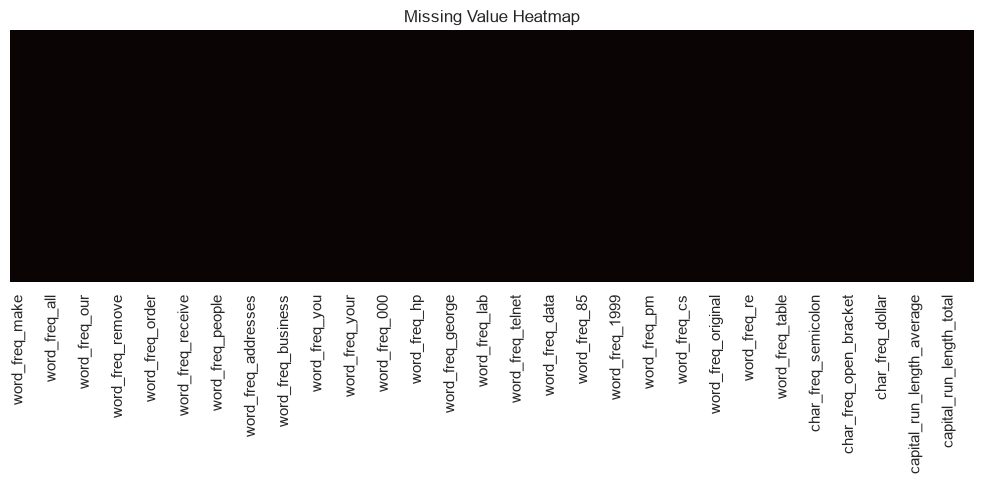

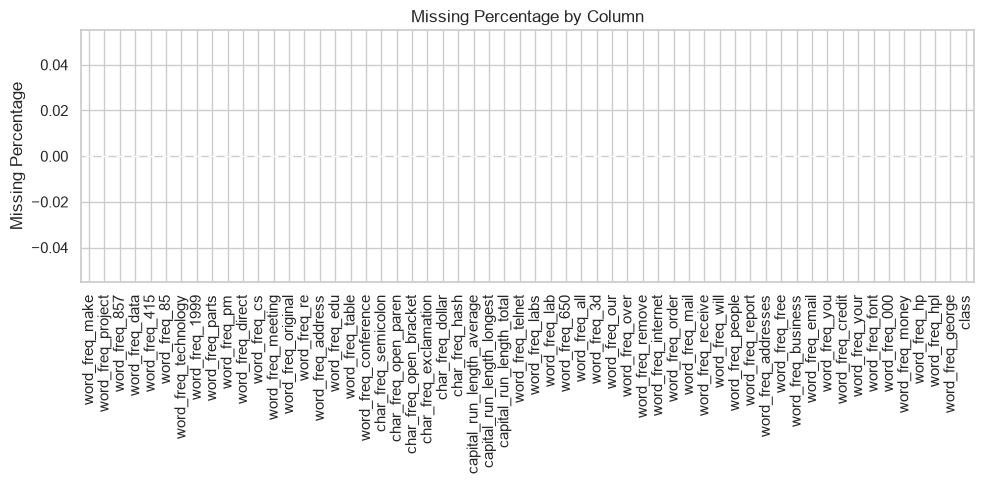

,column,missing_%
0,word_freq_make,0.0
1,word_freq_project,0.0
2,word_freq_857,0.0
3,word_freq_data,0.0
4,word_freq_415,0.0
5,word_freq_85,0.0
6,word_freq_technology,0.0
7,word_freq_1999,0.0
8,word_freq_parts,0.0
9,word_freq_pm,0.0


,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,word_freq_make,0.0000,0.0000,1053,90
1,word_freq_address,0.0000,0.0000,898,43
2,word_freq_all,-0.6300,1.0500,338,94
3,word_freq_3d,0.0000,0.0000,47,13
4,word_freq_our,-0.5700,0.9500,501,81
5,word_freq_over,0.0000,0.0000,999,104
6,word_freq_remove,0.0000,0.0000,807,99
7,word_freq_internet,0.0000,0.0000,824,77
8,word_freq_order,0.0000,0.0000,773,113
9,word_freq_mail,-0.2400,0.4000,852,74


word_freq_make: IQR=1053, Z-score=90
word_freq_address: IQR=898, Z-score=43
word_freq_all: IQR=338, Z-score=94
word_freq_3d: IQR=47, Z-score=13
word_freq_our: IQR=501, Z-score=81
word_freq_over: IQR=999, Z-score=104
word_freq_remove: IQR=807, Z-score=99
word_freq_internet: IQR=824, Z-score=77
word_freq_order: IQR=773, Z-score=113
word_freq_mail: IQR=852, Z-score=74
word_freq_receive: IQR=709, Z-score=100
word_freq_will: IQR=270, Z-score=102
word_freq_people: IQR=852, Z-score=89
word_freq_report: IQR=357, Z-score=106
word_freq_addresses: IQR=336, Z-score=99
word_freq_free: IQR=957, Z-score=69
word_freq_business: IQR=963, Z-score=97
word_freq_email: IQR=1038, Z-score=106
word_freq_you: IQR=75, Z-score=60
word_freq_credit: IQR=424, Z-score=76
word_freq_your: IQR=229, Z-score=87
word_freq_font: IQR=117, Z-score=57
word_freq_000: IQR=679, Z-score=107
word_freq_money: IQR=735, Z-score=32
word_freq_hp: IQR=1090, Z-score=86
word_freq_hpl: IQR=811, Z-score=105
word_freq_george: IQR=780, Z-score

,feature,test,statistic,p_value,normal
0,word_freq_make,Shapiro,0.387161,1.498811e-82,False
1,word_freq_address,Shapiro,0.140053,3.879271e-90,False
2,word_freq_all,Shapiro,0.619466,1.869711e-72,False
3,word_freq_3d,Shapiro,0.022553,4.282842e-93,False
4,word_freq_our,Shapiro,0.514678,1.594122e-77,False
5,word_freq_over,Shapiro,0.397545,3.543808e-82,False
6,word_freq_remove,Shapiro,0.324377,1.062522e-84,False
7,word_freq_internet,Shapiro,0.276978,3.276529e-86,False
8,word_freq_order,Shapiro,0.370011,3.718693e-83,False
9,word_freq_mail,Shapiro,0.404045,6.112760e-82,False


,feature,test,statistic,p_value
0,word_freq_make,ANOVA,74.440200,8.487764e-18
1,word_freq_address,ANOVA,4.204865,4.036473e-02
2,word_freq_all,ANOVA,185.665407,1.776872e-41
3,word_freq_3d,ANOVA,15.187489,9.873095e-05
4,word_freq_our,ANOVA,285.890659,2.872077e-62
5,word_freq_over,ANOVA,263.060625,1.423646e-57
6,word_freq_remove,ANOVA,570.169634,6.791279e-119
7,word_freq_internet,ANOVA,205.486673,1.259444e-45
8,word_freq_order,ANOVA,260.549947,4.690073e-57
9,word_freq_mail,ANOVA,90.557555,2.817050e-21


**Pearson Correlation Matrix**

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total
word_freq_make,1.000000,-0.016759,0.065627,0.013273,0.023119,0.059674,0.007669,-0.003950,0.106263,0.041198,...,-0.017755,-0.026505,-0.021196,-0.033301,0.058292,0.117419,-0.008844,0.044491,0.061382,0.089165
word_freq_address,-0.016759,1.000000,-0.033526,-0.006923,-0.023760,-0.024840,0.003918,-0.016280,-0.003826,0.032962,...,-0.015747,-0.007282,-0.049837,-0.018527,-0.014461,-0.009605,0.001946,0.002083,0.000271,-0.022680
word_freq_all,0.065627,-0.033526,1.000000,-0.020246,0.077734,0.087564,0.036677,0.012003,0.093786,0.032075,...,-0.026344,-0.033213,-0.016495,-0.033120,0.108140,0.087618,-0.003336,0.097398,0.107463,0.070114
word_freq_3d,0.013273,-0.006923,-0.020246,1.000000,0.003238,-0.010014,0.019784,0.010268,-0.002454,-0.004947,...,-0.001924,-0.000591,-0.012370,-0.007148,-0.003138,0.010862,-0.000298,0.005260,0.022081,0.021369
word_freq_our,0.023119,-0.023760,0.077734,0.003238,1.000000,0.054054,0.147336,0.029598,0.020823,0.034495,...,-0.032005,-0.032759,-0.046361,-0.026390,0.025509,0.041582,0.002016,0.052662,0.052290,0.002492
word_freq_over,0.059674,-0.024840,0.087564,-0.010014,0.054054,1.000000,0.061163,0.079561,0.117438,0.013897,...,-0.031693,-0.019119,-0.008705,-0.015133,0.065043,0.105692,0.019894,-0.010278,0.090172,0.082089
word_freq_remove,0.007669,0.003918,0.036677,0.019784,0.147336,0.061163,1.000000,0.044545,0.050786,0.056809,...,-0.031408,-0.033089,-0.051885,-0.027653,0.053706,0.070127,0.046612,0.041565,0.059677,-0.008344
word_freq_internet,-0.003950,-0.016280,0.012003,0.010268,0.029598,0.079561,0.044545,1.000000,0.105302,0.083129,...,-0.021224,-0.027432,-0.032494,-0.019548,0.031454,0.057910,-0.008012,0.011254,0.037575,0.040252
word_freq_order,0.106263,-0.003826,0.093786,-0.002454,0.020823,0.117438,0.050786,0.105302,1.000000,0.130624,...,-0.026017,-0.014646,-0.031003,0.013601,0.043639,0.149365,-0.000522,0.111308,0.189247,0.248724
word_freq_mail,0.041198,0.032962,0.032075,-0.004947,0.034495,0.013897,0.056809,0.083129,0.130624,1.000000,...,-0.016842,0.011945,0.003936,0.007357,0.036737,0.075786,0.044830,0.073677,0.103308,0.087273


**Spearman Correlation Matrix**

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total
word_freq_make,1.000000,0.204864,0.304347,0.025293,0.234206,0.319568,0.154093,0.233446,0.390119,0.249177,...,0.043153,0.163999,0.071795,0.057894,0.250306,0.373471,0.204609,0.220538,0.331056,0.408163
word_freq_address,0.204864,1.000000,0.243308,-0.024941,0.229600,0.228421,0.246619,0.279267,0.295702,0.387784,...,-0.009185,0.060055,0.037135,-0.008305,0.241885,0.304505,0.313758,0.287246,0.369835,0.372565
word_freq_all,0.304347,0.243308,1.000000,0.016732,0.341889,0.300235,0.223852,0.224608,0.297184,0.210350,...,0.008664,0.090498,0.104551,-0.005808,0.339106,0.363732,0.193838,0.219852,0.359123,0.435758
word_freq_3d,0.025293,-0.024941,0.016732,1.000000,0.037131,-0.006343,0.050105,0.062579,0.027336,0.019374,...,-0.001228,0.055385,0.003036,-0.003343,0.060241,0.042906,0.074582,0.090679,0.099529,0.111379
word_freq_our,0.234206,0.229600,0.341889,0.037131,1.000000,0.280136,0.345737,0.239225,0.232251,0.230423,...,0.012513,0.055131,0.061141,0.013606,0.278286,0.320438,0.144310,0.213216,0.341037,0.417327
word_freq_over,0.319568,0.228421,0.300235,-0.006343,0.280136,1.000000,0.259031,0.365759,0.355208,0.222430,...,0.001888,0.142312,0.085620,0.050504,0.215433,0.364084,0.232278,0.189814,0.322244,0.423401
word_freq_remove,0.154093,0.246619,0.223852,0.050105,0.345737,0.259031,1.000000,0.227255,0.197356,0.265370,...,-0.076040,-0.059936,-0.023389,-0.037319,0.327541,0.344427,0.225420,0.302752,0.339006,0.317813
word_freq_internet,0.233446,0.279267,0.224608,0.062579,0.239225,0.365759,0.227255,1.000000,0.318675,0.278240,...,0.001415,0.088683,0.066789,0.020288,0.212648,0.391108,0.188670,0.202328,0.316723,0.393007
word_freq_order,0.390119,0.295702,0.297184,0.027336,0.232251,0.355208,0.197356,0.318675,1.000000,0.328406,...,0.010256,0.167059,0.101770,0.121944,0.241514,0.443328,0.275193,0.311283,0.430988,0.497484
word_freq_mail,0.249177,0.387784,0.210350,0.019374,0.230423,0.222430,0.265370,0.278240,0.328406,1.000000,...,-0.001054,0.082471,0.116439,0.068097,0.249407,0.302241,0.274839,0.338184,0.395933,0.417209


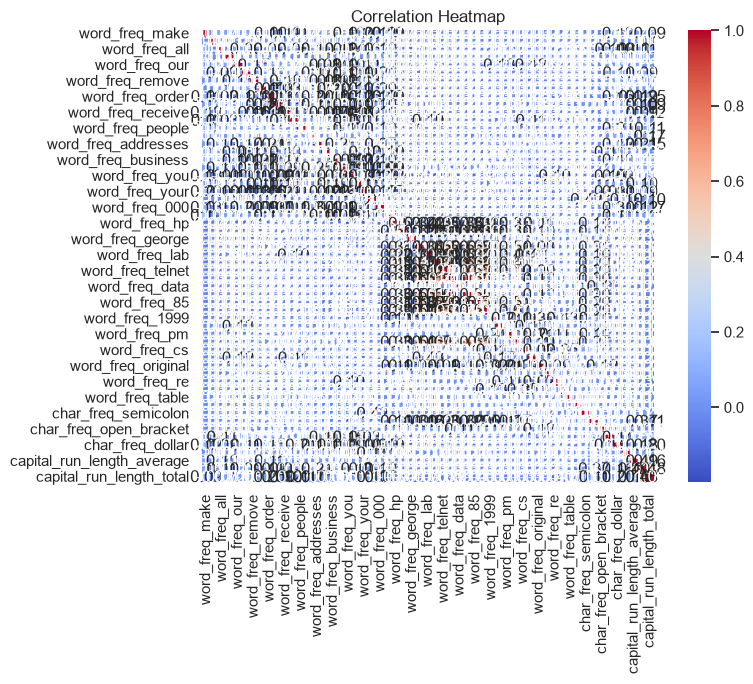

Highly correlated pairs: 3


,feature_1,feature_2,correlation
0,word_freq_857,word_freq_415,0.996066
1,word_freq_857,word_freq_direct,0.848021
2,word_freq_415,word_freq_direct,0.845359


,class,count
0,0,2788
1,1,1813


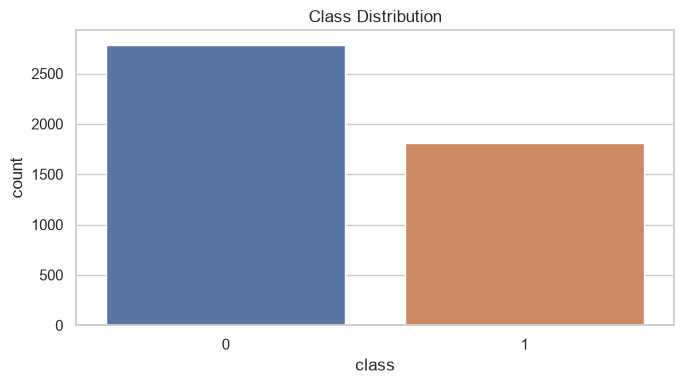

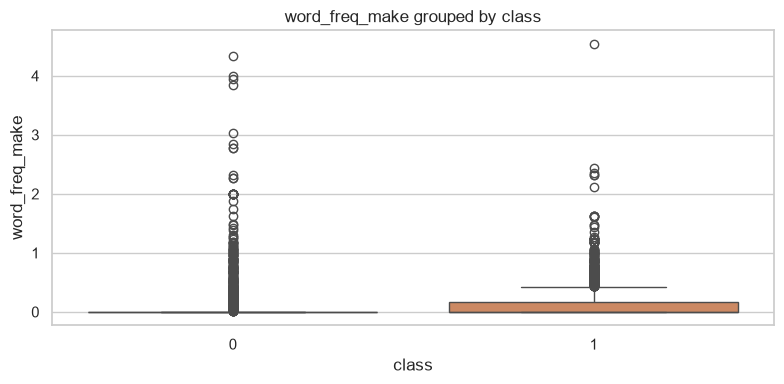

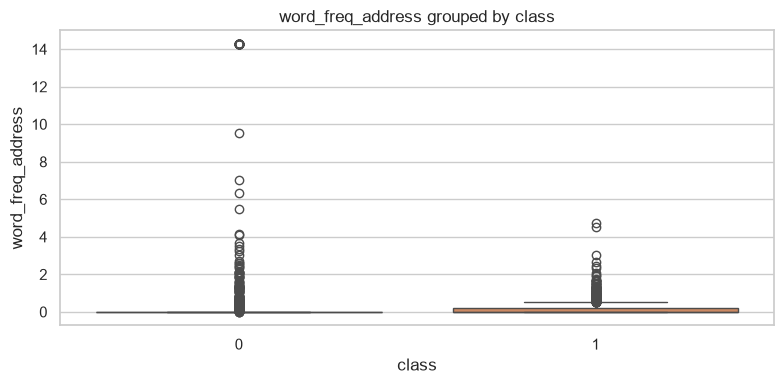

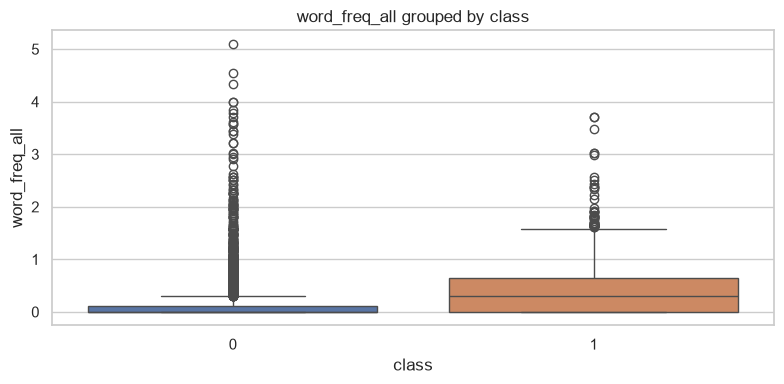

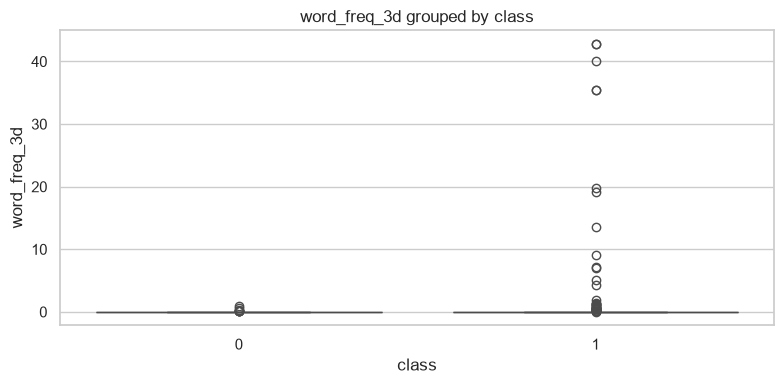

Training shape: (3680, 57)
Testing shape: (921, 57)
Encoded features: 0


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_semicolon,char_freq_open_paren,char_freq_open_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total
2940,-0.183216,-0.166310,0.355314,-0.04948,-0.248384,0.003308,-0.288445,-0.289119,1.605406,-0.372789,...,-0.106214,0.661859,0.178468,0.280509,-0.316336,-0.244193,-0.092223,-0.071989,-0.033457,1.380289
1303,0.194418,0.031873,1.887235,-0.04948,0.170213,1.742532,0.782699,0.454448,2.096130,0.446544,...,-0.106214,-0.153831,-0.122845,-0.145265,0.005037,0.639845,-0.062152,0.034503,2.574737,1.888085
3468,-0.340564,-0.166310,-0.551745,-0.04948,-0.472632,-0.344536,-0.288445,-0.289119,-0.322438,-0.372789,...,-0.106214,-0.153831,-0.496888,-0.145265,-0.134896,-0.298239,-0.092223,-0.100680,-0.217679,-0.378921
3181,-0.340564,-0.166310,-0.551745,-0.04948,-0.472632,-0.344536,-0.288445,-0.289119,-0.322438,-0.372789,...,-0.106214,-0.153831,-0.496888,-0.145265,-0.316336,-0.298239,-0.092223,-0.027968,-0.154656,-0.434004
794,-0.340564,0.260547,-0.551745,-0.04948,0.364562,-0.344536,-0.288445,-0.289119,3.217784,0.509570,...,-0.106214,-0.153831,0.147297,-0.145265,-0.249927,-0.082055,-0.092223,-0.094014,0.005326,0.436994


,feature,select_k_best_score,p_value,mutual_information
52,char_freq_dollar,407.749689,4.463627e-86,0.204981
51,char_freq_exclamation,190.643330,2.570712e-42,0.199113
55,capital_run_length_longest,162.692731,1.713058e-36,0.192971
20,word_freq_your,688.058567,3.589011e-139,0.176450
54,capital_run_length_average,45.752312,1.554775e-11,0.169185
15,word_freq_free,240.144009,1.617101e-52,0.148177
6,word_freq_remove,442.755339,6.608577e-93,0.141634
56,capital_run_length_total,242.724991,4.793448e-53,0.130185
24,word_freq_hp,260.346148,1.216363e-56,0.123209
23,word_freq_money,189.128850,5.301550e-42,0.121599


,component,explained_variance_ratio
0,PC1,0.1182
1,PC2,0.0573


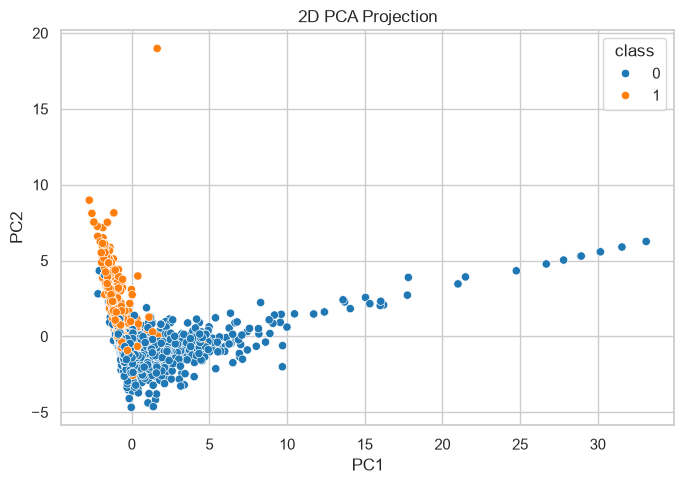

Dataset contains 4601 samples and 58 columns.
Detected 57 numerical features and 0 categorical features.
Target column `class` is treated as Categorical; task type is classification.
Duplicate rows: 391.
Columns with missing values: 0.
Highly correlated feature pairs: 3.
Constant features: None.
Suggested models: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM.
Report saved to: classification_output/eda_reuse/eda_report.md
Plots saved to: classification_output/eda_reuse/plots
Received preprocessed data from EDA notebook
X_train: (3680, 57)
X_test: (921, 57)
Features: 57


,class,train_count
0,0,2230
1,1,1450


In [3]:
%run $EDA_NOTEBOOK_PATH

assert problem_type == "classification", "This notebook requires a classification target."
print("Received preprocessed data from EDA notebook")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")
display(pd.Series(y_train).value_counts().rename_axis(TARGET_COLUMN).reset_index(name="train_count"))

## Reusable Evaluation Pipeline

All current and future classifiers use the same training, timing, metric, and plotting helpers.

In [4]:
results = []
model_store = {}
classes = np.array(sorted(pd.Series(y_train).dropna().unique()))

def predict_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores if scores.ndim > 1 else np.vstack([1 - scores, scores]).T
    return None

def metric_dict(y_true, y_pred, y_score=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ROC-AUC": np.nan,
    }
    if y_score is not None:
        try:
            metrics["ROC-AUC"] = roc_auc_score(y_true, y_score, multi_class="ovr", average="weighted", labels=classes) if len(classes) > 2 else roc_auc_score(y_true, y_score[:, 1])
        except Exception:
            pass
    return metrics

def plot_confusion_matrix(model_name, y_true, y_pred):
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=classes), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, f"confusion_matrix_{model_name}.png"), bbox_inches="tight")
    plt.show()

def plot_roc_pr(model_name, y_true, y_score):
    if y_score is None:
        return
    lb = LabelBinarizer().fit(classes)
    y_bin = lb.transform(y_true)
    y_bin = np.column_stack([1 - y_bin, y_bin]) if len(classes) == 2 and y_bin.shape[1] == 1 else y_bin
    plt.figure(figsize=(6, 4))
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f"{label} AUC={auc(fpr, tpr):.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, f"roc_curve_{model_name}.png"), bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6, 4))
    for i, label in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, label=str(label))
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, f"precision_recall_{model_name}.png"), bbox_inches="tight")
    plt.show()

def train_and_evaluate_model(model_name, estimator, Xtr=X_train, Xte=X_test, ytr=y_train, yte=y_test, plot=True):
    model = clone(estimator)
    start = time.perf_counter()
    model.fit(Xtr, ytr)
    training_time = time.perf_counter() - start
    start = time.perf_counter()
    y_pred = model.predict(Xte)
    prediction_time = time.perf_counter() - start
    y_score = predict_scores(model, Xte)
    row = {"Model": model_name, **metric_dict(yte, y_pred, y_score), "Training Time": training_time, "Prediction Time": prediction_time}
    results.append(row)
    model_store[model_name] = model
    display(pd.DataFrame([row]))
    print(classification_report(yte, y_pred, zero_division=0))
    if plot:
        plot_confusion_matrix(model_name, yte, y_pred)
        plot_roc_pr(model_name, yte, y_score)
    return model, row

## Gaussian Naive Bayes

Train and evaluate Gaussian Naive Bayes using the common evaluation pipeline.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,Gaussian NB,0.83279,0.866565,0.83279,0.834536,0.937612,0.001444,0.000428


              precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921



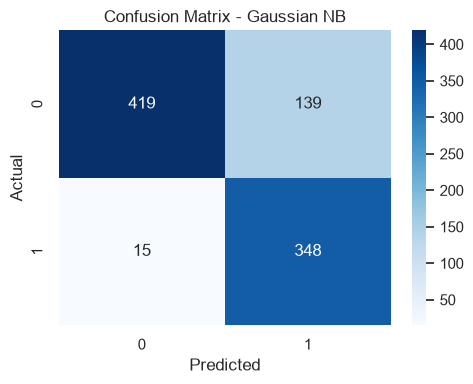

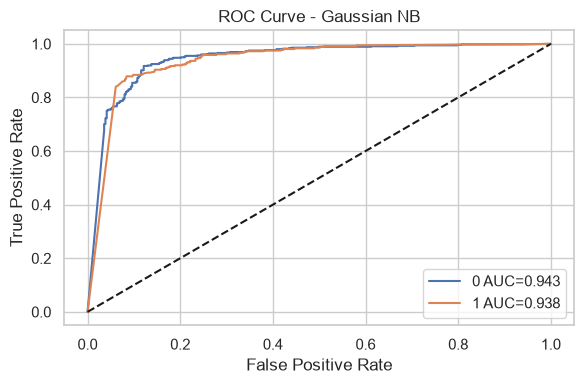

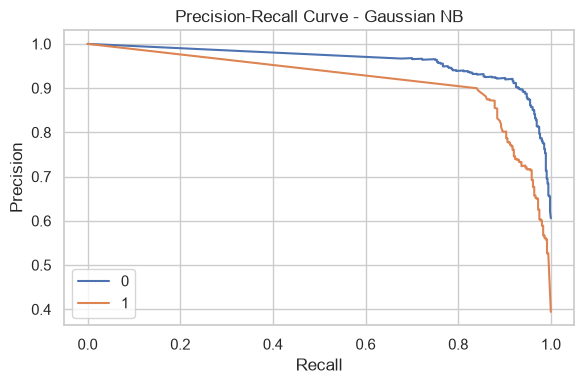

In [5]:
gaussian_model, gaussian_row = train_and_evaluate_model("Gaussian NB", GaussianNB())

## Multinomial Naive Bayes

Use a model-specific non-negative transform because Multinomial NB requires non-negative inputs.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,Multinomial NB,0.895765,0.89933,0.895765,0.8939,0.961191,0.002095,0.000419


              precision    recall  f1-score   support

           0       0.88      0.96      0.92       558
           1       0.93      0.79      0.86       363

    accuracy                           0.90       921
   macro avg       0.91      0.88      0.89       921
weighted avg       0.90      0.90      0.89       921



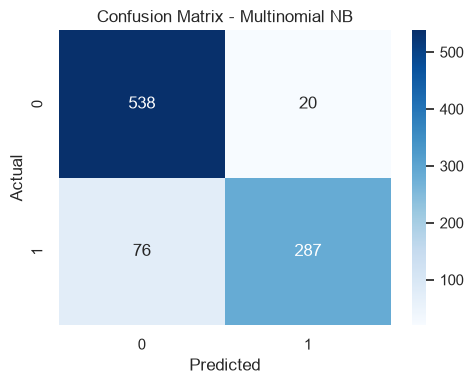

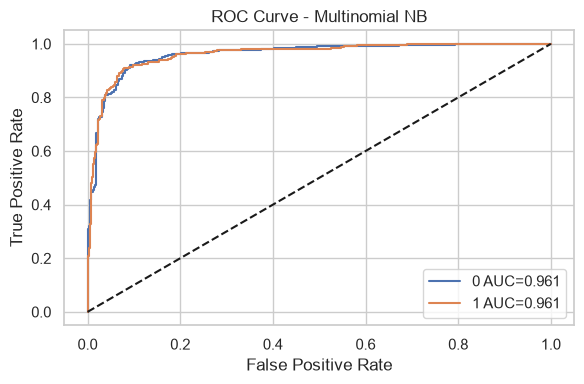

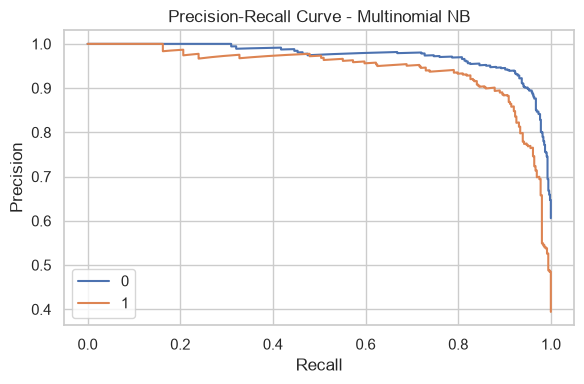

In [6]:
multinomial_model, multinomial_row = train_and_evaluate_model("Multinomial NB", Pipeline([("minmax", MinMaxScaler()), ("model", MultinomialNB())]))

## Bernoulli Naive Bayes

Train and evaluate Bernoulli Naive Bayes using the common evaluation pipeline.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,Bernoulli NB,0.901194,0.901245,0.901194,0.900515,0.960393,0.002184,0.000609


              precision    recall  f1-score   support

           0       0.90      0.94      0.92       558
           1       0.90      0.84      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.90       921
weighted avg       0.90      0.90      0.90       921



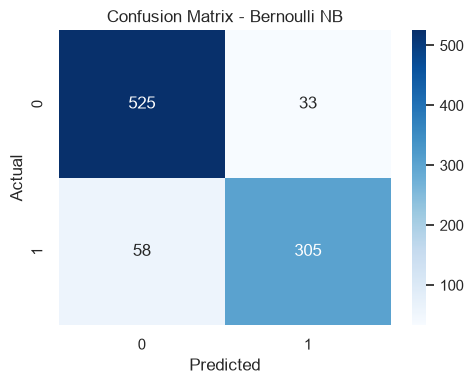

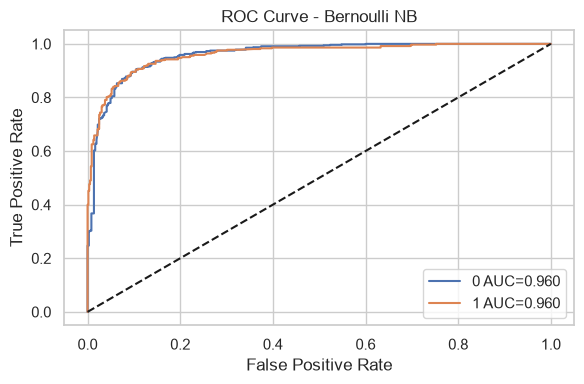

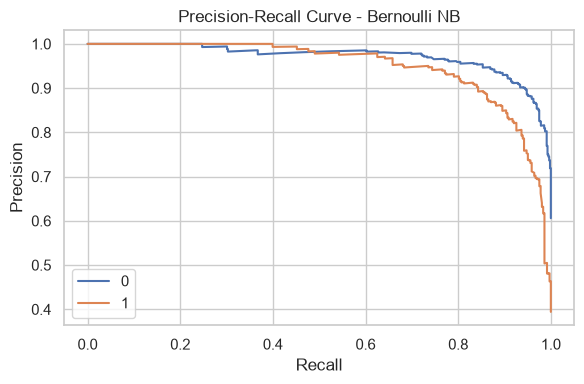

In [7]:
bernoulli_model, bernoulli_row = train_and_evaluate_model("Bernoulli NB", BernoulliNB())

## KNN: Effect of k

Evaluate KNN for k values specified in Experiment 2 and plot accuracy versus k.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,KNN k=1,0.899023,0.898777,0.899023,0.898846,0.892599,0.000996,0.050459


              precision    recall  f1-score   support

           0       0.91      0.92      0.92       558
           1       0.88      0.86      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,KNN k=3,0.897937,0.897846,0.897937,0.897887,0.936044,0.000748,0.003024


              precision    recall  f1-score   support

           0       0.91      0.92      0.92       558
           1       0.87      0.87      0.87       363

    accuracy                           0.90       921
   macro avg       0.89      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,KNN k=5,0.907709,0.907594,0.907709,0.907641,0.950564,0.000787,0.00323


...

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,KNN k=9,0.908795,0.908571,0.908795,0.908611,0.960208,0.000736,0.004055


              precision    recall  f1-score   support

           0       0.92      0.93      0.93       558
           1       0.89      0.87      0.88       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.90       921
weighted avg       0.91      0.91      0.91       921



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,KNN k=11,0.909881,0.909656,0.909881,0.909578,0.962173,0.000659,0.003596


              precision    recall  f1-score   support

           0       0.92      0.94      0.93       558
           1       0.90      0.87      0.88       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



,k,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,1,0.899023,0.898777,0.899023,0.898846,0.000996,0.050459
1,3,0.897937,0.897846,0.897937,0.897887,0.000748,0.003024
2,5,0.907709,0.907594,0.907709,0.907641,0.000787,0.003230
3,7,0.908795,0.908571,0.908795,0.908611,0.000712,0.003741
4,9,0.908795,0.908571,0.908795,0.908611,0.000736,0.004055
5,11,0.909881,0.909656,0.909881,0.909578,0.000659,0.003596


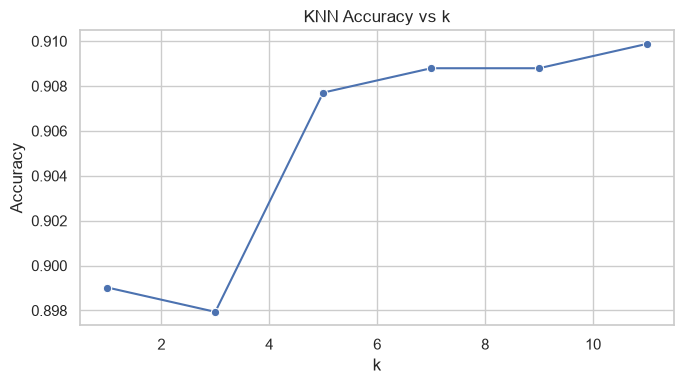

Best k based on F1: 11


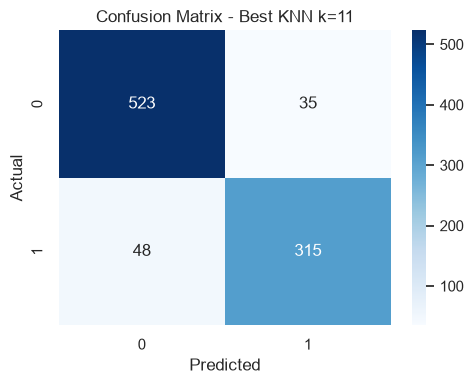

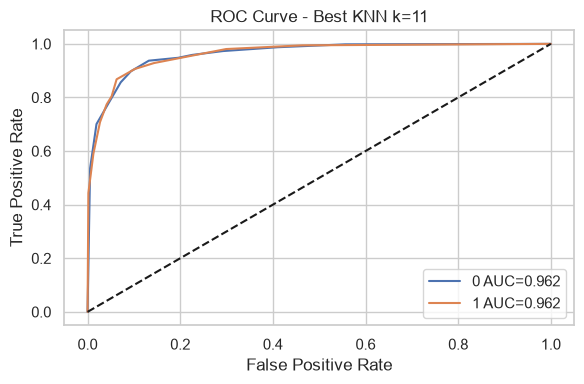

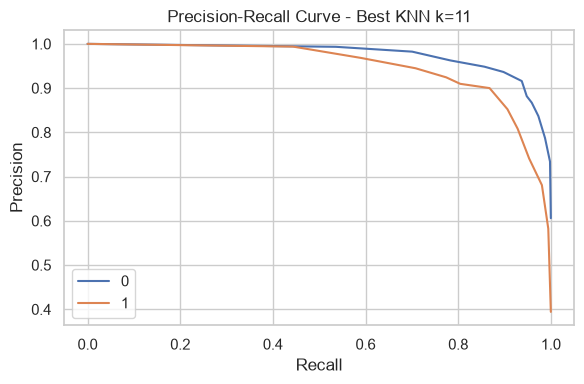

In [8]:
knn_rows = []
for k in [1, 3, 5, 7, 9, 11]:
    model, row = train_and_evaluate_model(f"KNN k={k}", KNeighborsClassifier(n_neighbors=k), plot=False)
    knn_rows.append({"k": k, **{m: row[m] for m in ["Accuracy", "Precision", "Recall", "F1", "Training Time", "Prediction Time"]}})

knn_comparison = pd.DataFrame(knn_rows)
display(knn_comparison)

plt.figure(figsize=(7, 4))
sns.lineplot(data=knn_comparison, x="k", y="Accuracy", marker="o")
plt.title("KNN Accuracy vs k")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "accuracy_vs_k.png"), bbox_inches="tight")
plt.show()

best_k = int(knn_comparison.sort_values(["F1", "Accuracy"], ascending=False).iloc[0]["k"])
best_knn_model = model_store[f"KNN k={best_k}"]
print(f"Best k based on F1: {best_k}")
plot_confusion_matrix(f"Best KNN k={best_k}", y_test, best_knn_model.predict(X_test))
plot_roc_pr(f"Best KNN k={best_k}", y_test, predict_scores(best_knn_model, X_test))

## Hyperparameter Tuning

Compare GridSearchCV and RandomizedSearchCV for KNN.

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,9,9
1,Metric,manhattan,manhattan
2,Weights,distance,distance
3,Algorithm,auto,kd_tree
4,CV Accuracy,0.925272,0.925272
5,Execution Time,2.854243,0.339563


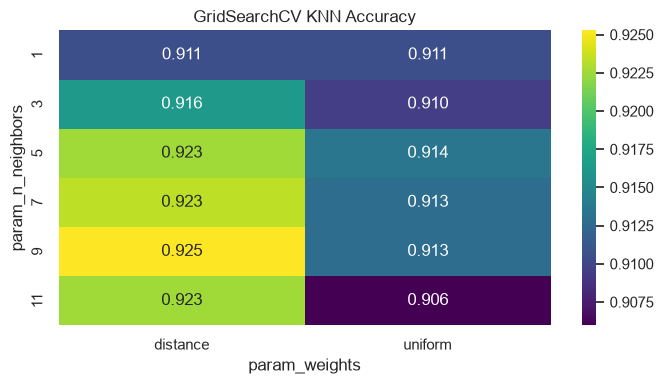

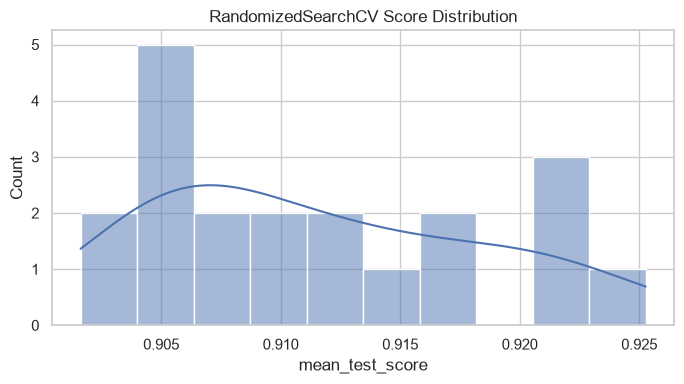

In [9]:
param_grid = {"n_neighbors": [1, 3, 5, 7, 9, 11], "weights": ["uniform", "distance"], "algorithm": ["auto", "brute", "kd_tree", "ball_tree"], "metric": ["euclidean", "manhattan"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

start = time.perf_counter()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, scoring="accuracy", cv=cv, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.perf_counter() - start

start = time.perf_counter()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_grid, n_iter=20, scoring="accuracy", cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X_train, y_train)
random_time = time.perf_counter() - start

tuning_table = pd.DataFrame({
    "Parameter": ["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Execution Time"],
    "GridSearchCV": [grid_search.best_params_["n_neighbors"], grid_search.best_params_["metric"], grid_search.best_params_["weights"], grid_search.best_params_["algorithm"], grid_search.best_score_, grid_time],
    "RandomizedSearchCV": [random_search.best_params_["n_neighbors"], random_search.best_params_["metric"], random_search.best_params_["weights"], random_search.best_params_["algorithm"], random_search.best_score_, random_time],
})
display(tuning_table)

grid_results = pd.DataFrame(grid_search.cv_results_)
heatmap_data = grid_results.groupby(["param_n_neighbors", "param_weights"])["mean_test_score"].max().unstack()
plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", fmt=".3f")
plt.title("GridSearchCV KNN Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "grid_search_heatmap.png"), bbox_inches="tight")
plt.show()

random_results = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(7, 4))
sns.histplot(random_results["mean_test_score"], bins=10, kde=True)
plt.title("RandomizedSearchCV Score Distribution")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "random_search_distribution.png"), bbox_inches="tight")
plt.show()

## KDTree vs BallTree

Compare KNN tree algorithms using the same k and distance metric.

In [10]:
tree_rows = []
for algorithm in ["kd_tree", "ball_tree"]:
    model = KNeighborsClassifier(n_neighbors=best_k, algorithm=algorithm, metric="euclidean")
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start
    start = time.perf_counter()
    pred = model.predict(X_test)
    pred_time = time.perf_counter() - start
    tree_rows.append({"Algorithm": algorithm, "Accuracy": accuracy_score(y_test, pred), "Training Time": train_time, "Prediction Time": pred_time})

kd_ball_metrics = pd.DataFrame(tree_rows).set_index("Algorithm")
kd_ball_table = pd.DataFrame({
    "Metric": ["Accuracy", "Training Time", "Prediction Time"],
    "KDTree": [kd_ball_metrics.loc["kd_tree", "Accuracy"], kd_ball_metrics.loc["kd_tree", "Training Time"], kd_ball_metrics.loc["kd_tree", "Prediction Time"]],
    "BallTree": [kd_ball_metrics.loc["ball_tree", "Accuracy"], kd_ball_metrics.loc["ball_tree", "Training Time"], kd_ball_metrics.loc["ball_tree", "Prediction Time"]],
})
display(kd_ball_table)

,Metric,KDTree,BallTree
0,Accuracy,0.909881,0.909881
1,Training Time,0.002199,0.001984
2,Prediction Time,0.054388,0.052272


## Cross Validation

Perform 5-fold cross-validation for the best Naive Bayes model and best KNN model.

,Fold,Naive Bayes,Best KNN
0,1,0.917120,0.938859
1,2,0.907609,0.927989
2,3,0.889946,0.925272
3,4,0.898098,0.926630
4,5,0.899457,0.907609
5,Average,0.902446,0.925272


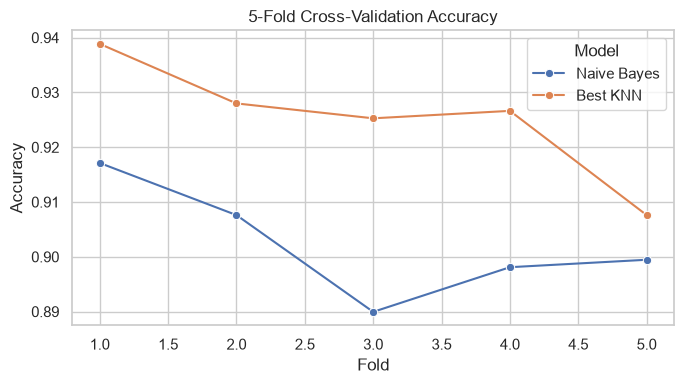

In [11]:
nb_rows = [row for row in results if row["Model"] in ["Gaussian NB", "Multinomial NB", "Bernoulli NB"]]
best_nb_name = max(nb_rows, key=lambda r: r["F1"])["Model"]
best_nb_estimator = model_store[best_nb_name]
best_knn_estimator = grid_search.best_estimator_

nb_scores = cross_val_score(best_nb_estimator, X_train, y_train, cv=cv, scoring="accuracy")
knn_scores = cross_val_score(best_knn_estimator, X_train, y_train, cv=cv, scoring="accuracy")
cv_table = pd.DataFrame({"Fold": [1, 2, 3, 4, 5], "Naive Bayes": nb_scores, "Best KNN": knn_scores})
cv_table = pd.concat([cv_table, pd.DataFrame([{"Fold": "Average", "Naive Bayes": nb_scores.mean(), "Best KNN": knn_scores.mean()}])], ignore_index=True)
display(cv_table)

cv_plot = cv_table[cv_table["Fold"] != "Average"].melt(id_vars="Fold", var_name="Model", value_name="Accuracy")
plt.figure(figsize=(7, 4))
sns.lineplot(data=cv_plot, x="Fold", y="Accuracy", hue="Model", marker="o")
plt.title("5-Fold Cross-Validation Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "cross_validation_accuracy.png"), bbox_inches="tight")
plt.show()

## Comparison Tables and Timing Analysis

Generate all required comparison tables from stored model results.

### Naive Bayes Comparison

,Gaussian,Multinomial,Bernoulli
Accuracy,0.832790,0.895765,0.901194
Precision,0.866565,0.899330,0.901245
Recall,0.832790,0.895765,0.901194
F1,0.834536,0.893900,0.900515
ROC-AUC,0.937612,0.961191,0.960393


### KNN Comparison

,k,Accuracy,Precision,Recall,F1
0,1,0.899023,0.898777,0.899023,0.898846
1,3,0.897937,0.897846,0.897937,0.897887
2,5,0.907709,0.907594,0.907709,0.907641
3,7,0.908795,0.908571,0.908795,0.908611
4,9,0.908795,0.908571,0.908795,0.908611
5,11,0.909881,0.909656,0.909881,0.909578


### Grid Search vs Randomized Search

...

,Fold,Naive Bayes,Best KNN
0,1,0.917120,0.938859
1,2,0.907609,0.927989
2,3,0.889946,0.925272
3,4,0.898098,0.926630
4,5,0.899457,0.907609
5,Average,0.902446,0.925272


### Experimental Time Analysis

,Model,Training Time,Prediction Time
0,Gaussian NB,0.001444,0.000428
1,Multinomial NB,0.002095,0.000419
2,Bernoulli NB,0.002184,0.000609
8,KNN k=11,0.000659,0.003596


### Theoretical Complexity

,Algorithm,Training,Prediction
0,Naive Bayes,O(nd),O(d)
1,KNN (Brute),O(1),O(nd)
2,KDTree,O(nlog n),O(log n) avg
3,BallTree,O(nlog n),O(log n) avg


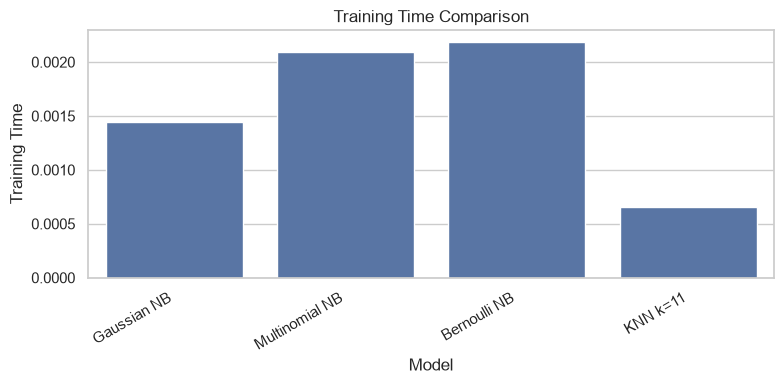

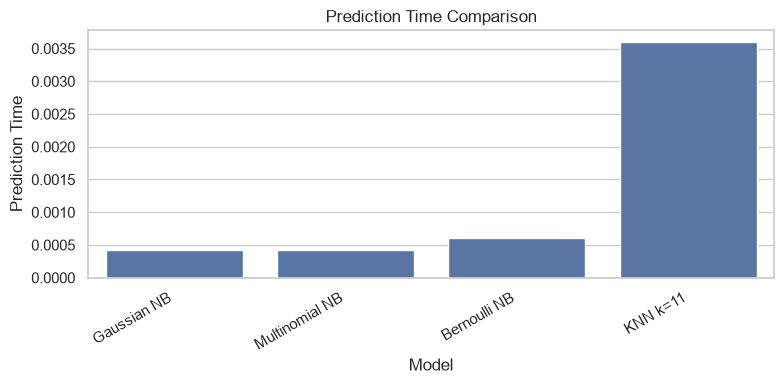

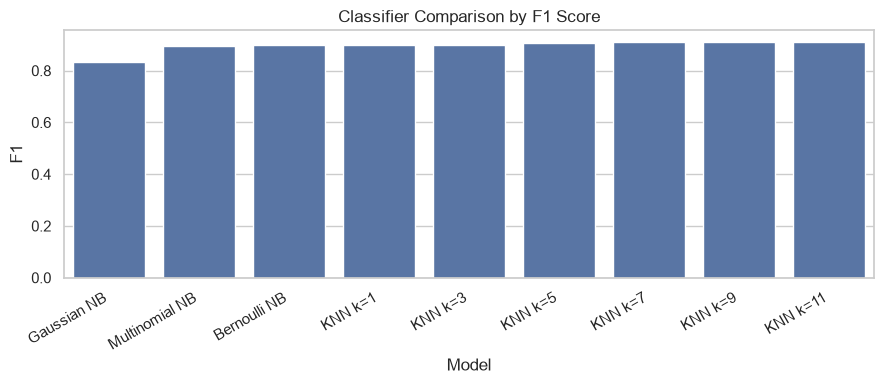

In [12]:
results_df = pd.DataFrame(results)
nb_comparison = results_df[results_df["Model"].isin(["Gaussian NB", "Multinomial NB", "Bernoulli NB"])].set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].T
nb_comparison.columns = [col.replace(" NB", "") for col in nb_comparison.columns]
knn_pdf_table = knn_comparison[["k", "Accuracy", "Precision", "Recall", "F1"]]
time_table = results_df[results_df["Model"].isin(["Gaussian NB", "Multinomial NB", "Bernoulli NB", f"KNN k={best_k}"])][["Model", "Training Time", "Prediction Time"]]
complexity_table = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "KNN (Brute)", "KDTree", "BallTree"],
    "Training": ["O(nd)", "O(1)", "O(nlog n)", "O(nlog n)"],
    "Prediction": ["O(d)", "O(nd)", "O(log n) avg", "O(log n) avg"],
})

display(Markdown("### Naive Bayes Comparison")); display(nb_comparison)
display(Markdown("### KNN Comparison")); display(knn_pdf_table)
display(Markdown("### Grid Search vs Randomized Search")); display(tuning_table)
display(Markdown("### KDTree vs BallTree")); display(kd_ball_table)
display(Markdown("### Cross Validation")); display(cv_table)
display(Markdown("### Experimental Time Analysis")); display(time_table)
display(Markdown("### Theoretical Complexity")); display(complexity_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=time_table, x="Model", y="Training Time")
plt.title("Training Time Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "training_time_comparison.png"), bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=time_table, x="Model", y="Prediction Time")
plt.title("Prediction Time Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "prediction_time_comparison.png"), bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="Model", y="F1")
plt.title("Classifier Comparison by F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CLASSIFICATION_PLOTS_DIRECTORY, "classifier_comparison.png"), bbox_inches="tight")
plt.show()

## Analysis Questions

Answer the required questions using the computed experimental results.

In [13]:
best_nb_metric = results_df[results_df["Model"].isin(["Gaussian NB", "Multinomial NB", "Bernoulli NB"])].sort_values("F1", ascending=False).iloc[0]
best_knn_metric = knn_comparison.sort_values(["F1", "Accuracy"], ascending=False).iloc[0]
preferred_search = "GridSearchCV" if grid_search.best_score_ >= random_search.best_score_ else "RandomizedSearchCV"
faster_tree = "KDTree" if kd_ball_table.loc[kd_ball_table["Metric"] == "Prediction Time", "KDTree"].iloc[0] <= kd_ball_table.loc[kd_ball_table["Metric"] == "Prediction Time", "BallTree"].iloc[0] else "BallTree"
large_dataset_choice = best_nb_metric["Model"] if best_nb_metric["F1"] >= best_knn_metric["F1"] * 0.98 else f"KNN k={int(best_knn_metric['k'])}"

analysis_answers = [
    f"Best Naive Bayes variant: {best_nb_metric['Model']} with F1={best_nb_metric['F1']:.4f}.",
    f"Optimal k: {int(best_knn_metric['k'])} with F1={best_knn_metric['F1']:.4f} and Accuracy={best_knn_metric['Accuracy']:.4f}.",
    f"{preferred_search} performed better by CV accuracy; Grid={grid_search.best_score_:.4f}, Randomized={random_search.best_score_:.4f}.",
    f"{faster_tree} had faster prediction time in the KDTree vs BallTree comparison.",
    "Practical timing follows the theory: Naive Bayes trains and predicts quickly, while KNN has low training cost but prediction depends on neighbor search.",
    f"Preferred large-dataset classifier from these results: {large_dataset_choice}.",
]
for answer in analysis_answers:
    print(answer)

Best Naive Bayes variant: Bernoulli NB with F1=0.9005.
Optimal k: 11 with F1=0.9096 and Accuracy=0.9099.
GridSearchCV performed better by CV accuracy; Grid=0.9253, Randomized=0.9253.
BallTree had faster prediction time in the KDTree vs BallTree comparison.
Practical timing follows the theory: Naive Bayes trains and predicts quickly, while KNN has low training cost but prediction depends on neighbor search.
Preferred large-dataset classifier from these results: Bernoulli NB.


## Conclusion and Report

Generate a concise conclusion and save the classification report without rerunning models.

In [14]:
conclusion = f"For {DATASET_NAME}, {best_nb_metric['Model']} was the best Naive Bayes model, while KNN performed best at k={int(best_knn_metric['k'])}. The final choice should balance F1 score, prediction time, and dataset size."
print(conclusion)

os.makedirs(CLASSIFICATION_OUTPUT, exist_ok=True)
report_path = os.path.join(CLASSIFICATION_OUTPUT, "classification_report.md")
report_parts = [
    "# Classification Report\n",
    f"## Aim\nClassify {DATASET_NAME} samples using Naive Bayes and KNN.\n",
    "## Naive Bayes Comparison\n" + nb_comparison.to_markdown() + "\n",
    "## KNN Comparison\n" + knn_pdf_table.to_markdown(index=False) + "\n",
    "## Grid Search vs Randomized Search\n" + tuning_table.to_markdown(index=False) + "\n",
    "## KDTree vs BallTree\n" + kd_ball_table.to_markdown(index=False) + "\n",
    "## Cross Validation\n" + cv_table.to_markdown(index=False) + "\n",
    "## Experimental Time Analysis\n" + time_table.to_markdown(index=False) + "\n",
    "## Theoretical Complexity\n" + complexity_table.to_markdown(index=False) + "\n",
    "## Analysis\n" + "\n".join(f"- {answer}" for answer in analysis_answers) + "\n",
    "## Conclusion\n" + conclusion + "\n",
]
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_parts))

print(f"Report saved to: {report_path}")
print(f"Plots saved to: {CLASSIFICATION_PLOTS_DIRECTORY}")

For Spambase, Bernoulli NB was the best Naive Bayes model, while KNN performed best at k=11. The final choice should balance F1 score, prediction time, and dataset size.
Report saved to: classification_output/classification_report.md
Plots saved to: classification_output/plots
